In [15]:
### Descriptive Analytics and Data Preprocessing

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv('sales_data_with_discounts.csv')
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [18]:
df = pd.read_csv("sales_data_with_discounts.csv",index_col=0) #To set the index col
df.head(5)

,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
Date,,,,,,,,,,,,
01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 450 entries, 01-04-2021 to 15-04-2021
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Day                450 non-null    str    
 1   SKU                450 non-null    str    
 2   City               450 non-null    str    
 3   Volume             450 non-null    int64  
 4   BU                 450 non-null    str    
 5   Brand              450 non-null    str    
 6   Model              450 non-null    str    
 7   Avg Price          450 non-null    int64  
 8   Total Sales Value  450 non-null    int64  
 9   Discount Rate (%)  450 non-null    float64
 10  Discount Amount    450 non-null    float64
 11  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), str(6)
memory usage: 45.7+ KB


In [20]:
#Identifying all numerical and categorical columns

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("\nCategorical Columns:", categorical_cols)

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

Categorical Columns: ['Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


C:\Users\Videep\AppData\Local\Temp\ipykernel_33444\1833218903.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [21]:
#Now for descriptive statistics
desc_stats = df[numerical_cols].describe()

desc_stats.loc['median'] = df[numerical_cols].median()
desc_stats.loc['mode'] = df[numerical_cols].mode().iloc[0]

desc_stats.round(2)

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.00,450.00,450.00,450.00,450.00,450.00
mean,5.07,10453.43,33812.84,15.16,3346.50,30466.34
std,4.23,18079.90,50535.07,4.22,4509.90,46358.66
min,1.00,290.00,400.00,5.01,69.18,326.97
25%,3.00,465.00,2700.00,13.97,460.46,2202.21
50%,4.00,1450.00,5700.00,16.58,988.93,4677.79
75%,6.00,10100.00,53200.00,18.11,5316.50,47847.91
max,31.00,60100.00,196400.00,19.99,25738.02,179507.48
median,4.00,1450.00,5700.00,16.58,988.93,4677.79
mode,3.00,400.00,24300.00,5.01,69.18,326.97


Observations:
* For total sales, the mean(33812.84) is high than the median(5700), this means that the data is right skewed.
* Volume shows variation which means fluctuating sales.
* Different Average Price tells us that there are low cost products as well as high cost products
* There is a difference in net sales and total sales, so it means they are giving discounts


## DATA VISUALIZATIONS

### Histograms

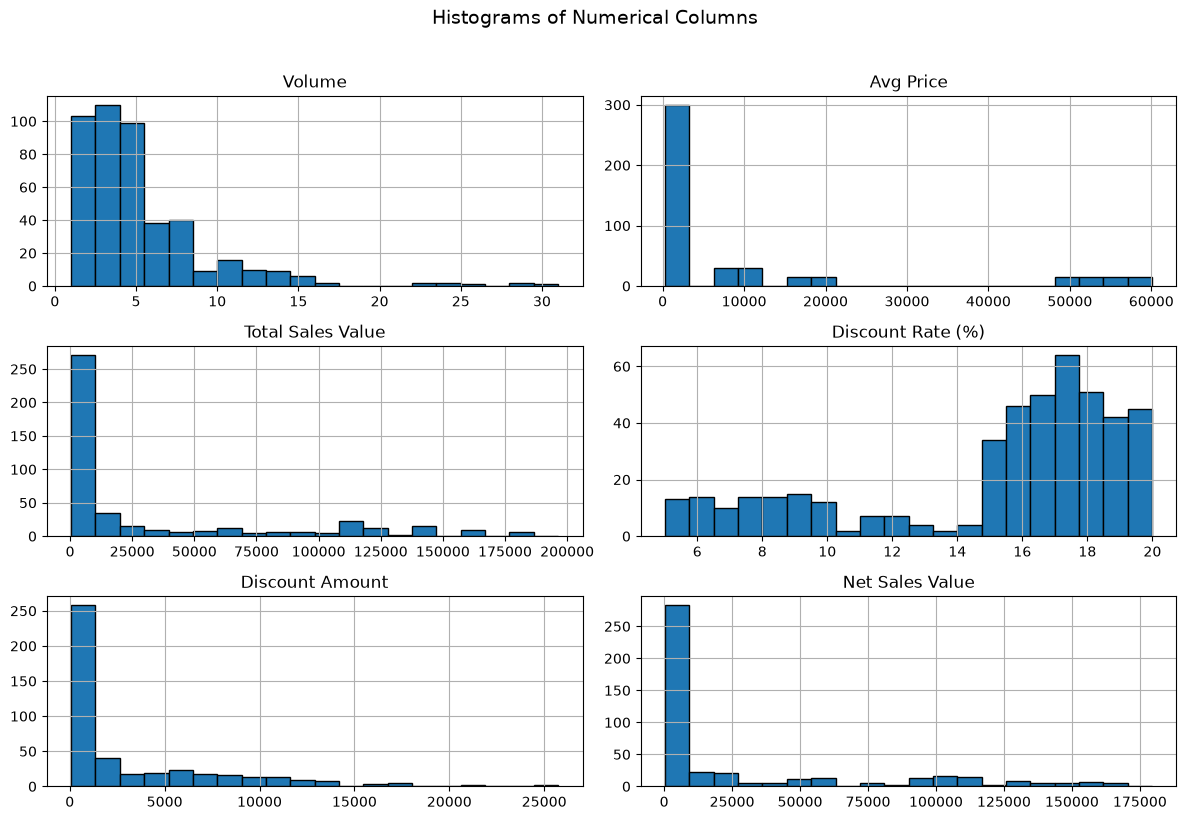

In [23]:
df[numerical_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numerical Columns", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Histogram Observations:**
* Volume: It is right-skewed, most transactions involve only 1–6 units, rare transactions involve 20+ units.
* Avg Price: It is right-skewed, the bulk of SKUs are low-priced (under ₹5,000) with a long tail of costly products.
* Total Sales Value & Net Sales Value: Both are right-skewed most sales are small, a small number of orders are bulk.
* Discount Rate (%): It is left skewed and most discounts offered are between 15-20%.
* Discount Amount: It is right-skewed, most discount are small.

### Boxplots

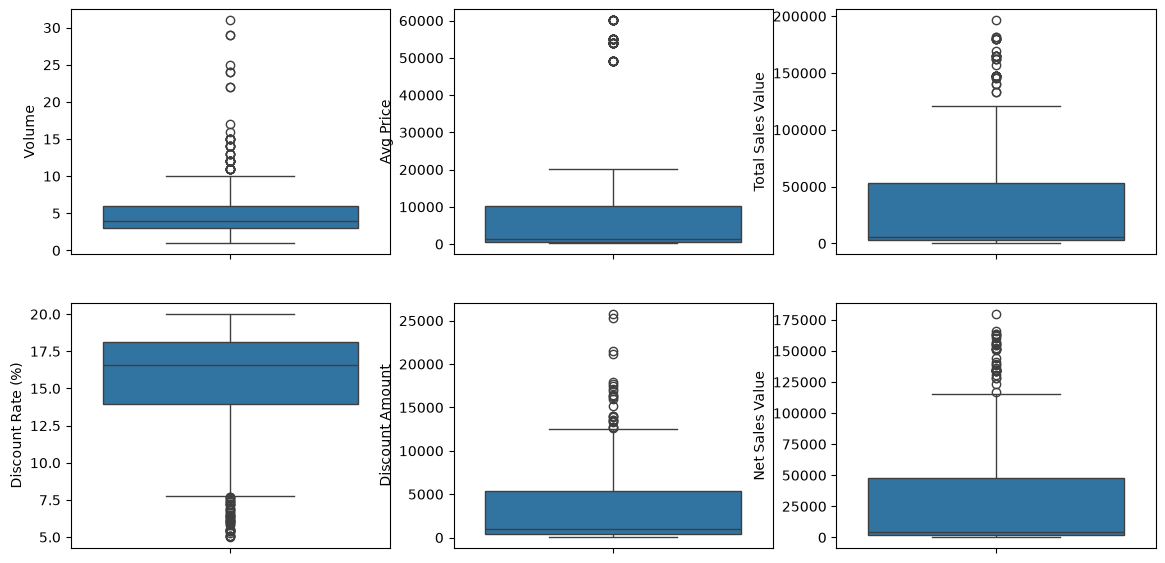

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14,7))

sn.boxplot(y=df["Volume"], ax=axes[0,0])
sn.boxplot(y=df["Avg Price"], ax=axes[0,1])
sn.boxplot(y=df["Total Sales Value"], ax=axes[0,2])
sn.boxplot(y=df["Discount Rate (%)"], ax=axes[1,0])
sn.boxplot(y=df["Discount Amount"], ax=axes[1,1])
sn.boxplot(y=df["Net Sales Value"], ax=axes[1,2])

plt.show()

**Boxplot Observations:**
* Volume: It is a small box which means most number of transactions occur within a small range.
* Avg Price: Most products are priced in a lower range with a few costly products.
* Total Sales Value & Net Sales Value: Most orders fall with in normal range but there are few costly orders.
* Discount Rate (%): Most discount rates are between 14-18% and only a few orders with less discount rate.
* Discount Amount: Most orders have a discount upto 5000 but few orders having high discount amount.

### Bar Chart Analysis

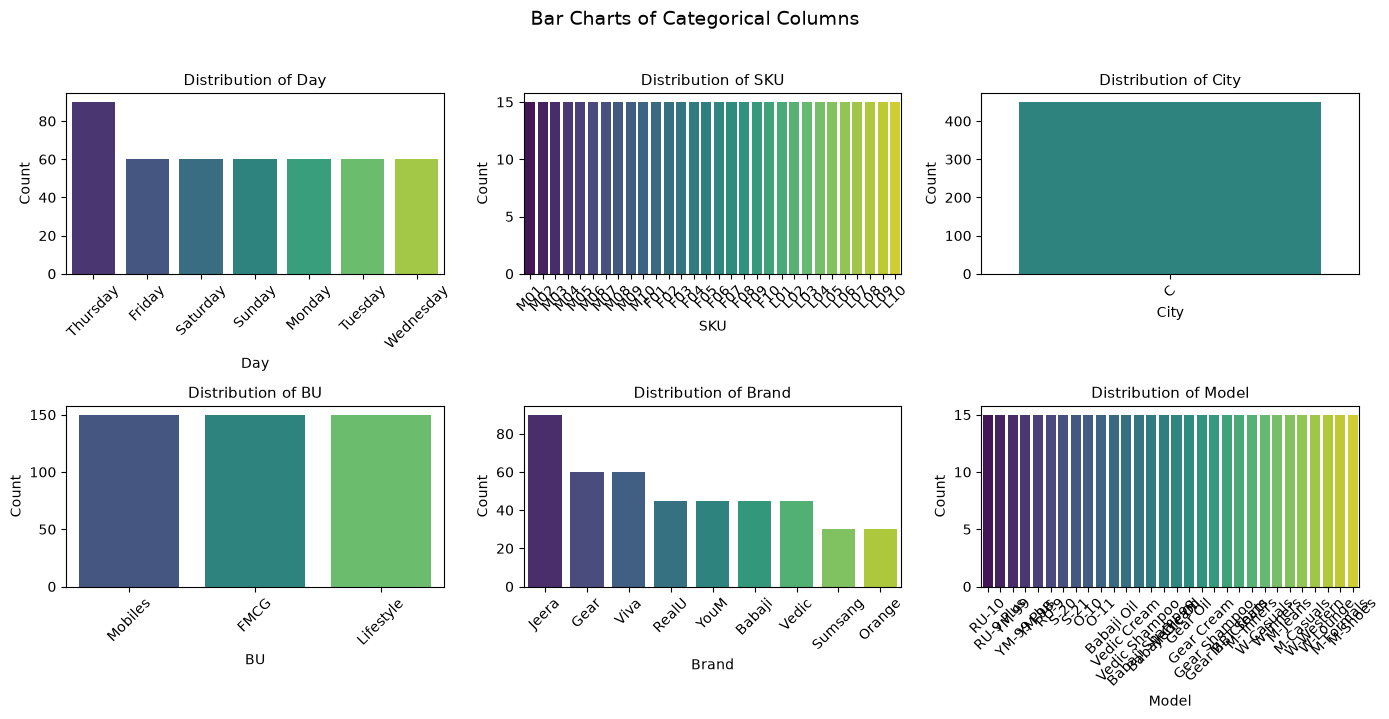

In [30]:
import warnings
warnings.filterwarnings("ignore")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, categorical_cols[:6]):
    counts = df[col].value_counts()
    sn.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(f"Distribution of {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Bar Charts of Categorical Columns", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Bar Charts Observation**

* Day:   Almost equal number of sales occur daily with Thursday having th ehighest number of sales.
* SKU:   All SKUs have equal number of entries indicating dataset is evenly distributed among different products.
* City:  All transactions are of a single city.
* BU:    They have an equal number of records showing equal distribution.
* Brand: Most occuring brand is the jeera followed by gear and viva.
* Model: All models have equally number of records indicating each model is equally distributed.

## Standardization of Numerical Variables

**What is Standardization?**  
Standardization (Z-score normalization) rescales each feature so that it has a mean of 0 and a standard deviation of 1.  
The formula is:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the column mean and $\sigma$ is the column standard deviation.  

In [31]:
# Before standardization — original values
print("=== Before Standardization ===")
print(df[numerical_cols].describe().round(2))

=== Before Standardization ===
       Volume  Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.00     450.00             450.00             450.00   
mean     5.07   10453.43           33812.84              15.16   
std      4.23   18079.90           50535.07               4.22   
min      1.00     290.00             400.00               5.01   
25%      3.00     465.00            2700.00              13.97   
50%      4.00    1450.00            5700.00              16.58   
75%      6.00   10100.00           53200.00              18.11   
max     31.00   60100.00          196400.00              19.99   

       Discount Amount  Net Sales Value  
count           450.00           450.00  
mean           3346.50         30466.34  
std            4509.90         46358.66  
min              69.18           326.97  
25%             460.46          2202.21  
50%             988.93          4677.79  
75%            5316.50         47847.91  
max           25738.02        179507.4

In [32]:
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("=== After Standardization ===")
print(df_standardized[numerical_cols].describe().round(2))

=== After Standardization ===
       Volume  Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.00     450.00             450.00             450.00   
mean     0.00       0.00               0.00              -0.00   
std      1.00       1.00               1.00               1.00   
min     -0.96      -0.56              -0.66              -2.41   
25%     -0.49      -0.55              -0.62              -0.28   
50%     -0.25      -0.50              -0.56               0.34   
75%      0.22      -0.02               0.38               0.70   
max      6.14       2.75               3.22               1.15   

       Discount Amount  Net Sales Value  
count           450.00           450.00  
mean             -0.00             0.00  
std               1.00             1.00  
min              -0.73            -0.65  
25%              -0.64            -0.61  
50%              -0.52            -0.56  
75%               0.44             0.38  
max               4.97             3.22

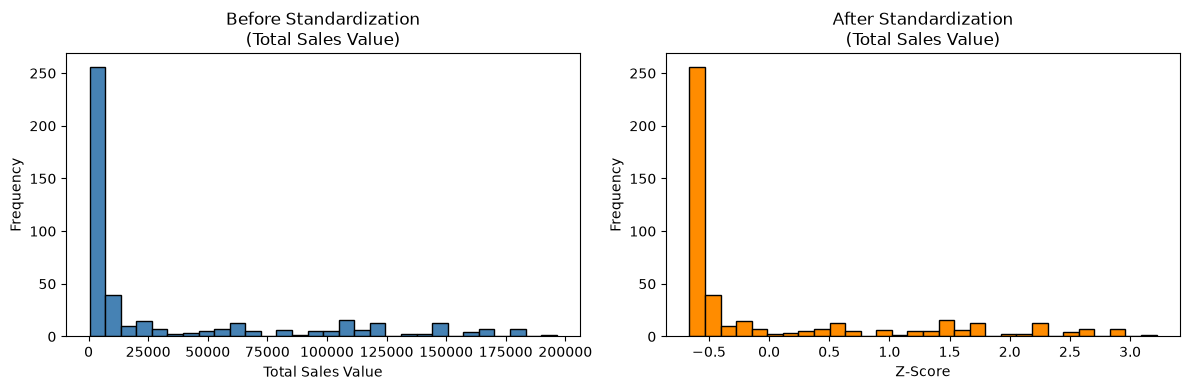

In [33]:
# Visual comparison: before vs after for 'Total Sales Value'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Total Sales Value'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Before Standardization\n(Total Sales Value)")
axes[0].set_xlabel("Total Sales Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_standardized['Total Sales Value'], bins=30, color='darkorange', edgecolor='black')
axes[1].set_title("After Standardization\n(Total Sales Value)")
axes[1].set_xlabel("Z-Score")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Conversion of Categorical Data into Dummy Variables

**What is One-Hot Encoding?**  
Most machine learning algorithms require purely numerical input. Categorical columns like *City*, *Brand*, or *Day* cannot be fed directly as text. **One-hot encoding** creates a binary (0/1) column for each unique category, representing membership without implying any ordinal relationship between categories.


In [34]:
# Display original categorical columns
print("Original categorical columns:", categorical_cols)
print("Original dataset shape:", df.shape)
print()
df[categorical_cols].head(5)

Original categorical columns: ['Day', 'SKU', 'City', 'BU', 'Brand', 'Model']
Original dataset shape: (450, 12)



,Day,SKU,City,BU,Brand,Model
Date,,,,,,
01-04-2021,Thursday,M01,C,Mobiles,RealU,RU-10
01-04-2021,Thursday,M02,C,Mobiles,RealU,RU-9 Plus
01-04-2021,Thursday,M03,C,Mobiles,YouM,YM-99
01-04-2021,Thursday,M04,C,Mobiles,YouM,YM-99 Plus
01-04-2021,Thursday,M05,C,Mobiles,YouM,YM-98


In [36]:
# Applying one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Encoded dataset shape:", df_encoded.shape)
print()

new_columns = []
for c in df_encoded.columns:
    if c not in numerical_cols:
        new_columns.append(c)

print("New columns added:", new_columns)

Encoded dataset shape: (450, 86)

New columns added: ['Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'SKU_F01', 'SKU_F02', 'SKU_F03', 'SKU_F04', 'SKU_F05', 'SKU_F06', 'SKU_F07', 'SKU_F08', 'SKU_F09', 'SKU_F10', 'SKU_L01', 'SKU_L02', 'SKU_L03', 'SKU_L04', 'SKU_L05', 'SKU_L06', 'SKU_L07', 'SKU_L08', 'SKU_L09', 'SKU_L10', 'SKU_M01', 'SKU_M02', 'SKU_M03', 'SKU_M04', 'SKU_M05', 'SKU_M06', 'SKU_M07', 'SKU_M08', 'SKU_M09', 'SKU_M10', 'City_C', 'BU_FMCG', 'BU_Lifestyle', 'BU_Mobiles', 'Brand_Babaji', 'Brand_Gear', 'Brand_Jeera', 'Brand_Orange', 'Brand_RealU', 'Brand_Sumsang', 'Brand_Vedic', 'Brand_Viva', 'Brand_YouM', 'Model_Babaji Cream', 'Model_Babaji Oil ', 'Model_Babaji Shampoo', 'Model_Gear BB Cream', 'Model_Gear Cream', 'Model_Gear Oil', 'Model_Gear Shampoo', 'Model_M- Inners', 'Model_M- T Shirts', 'Model_M-Casuals', 'Model_M-Formals', 'Model_M-Jeans', 'Model_M-Shoes', 'Model_O-10', 'Model_O-11', 'Model_RU-10', 'Model_RU-9', 'Mod

In [37]:
# Showing a portion of the transformed dataset (first 5 rows, first 20 columns)
df_encoded.iloc[:5, :20]

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,SKU_F01,SKU_F02,SKU_F03,SKU_F04,SKU_F05,SKU_F06,SKU_F07
Date,,,,,,,,,,,,,,,,,,,,
01-04-2021,15,12100,181500,11.654820,21153.498820,160346.501180,False,False,False,False,True,False,False,False,False,False,False,False,False,False
01-04-2021,10,10100,101000,11.560498,11676.102961,89323.897039,False,False,False,False,True,False,False,False,False,False,False,False,False,False
01-04-2021,7,16100,112700,9.456886,10657.910157,102042.089843,False,False,False,False,True,False,False,False,False,False,False,False,False,False
01-04-2021,6,20100,120600,6.935385,8364.074702,112235.925298,False,False,False,False,True,False,False,False,False,False,False,False,False,False
01-04-2021,3,8100,24300,17.995663,4372.946230,19927.053770,False,False,False,False,True,False,False,False,False,False,False,False,False,False


**One-Hot Encoding Observations:**
* The original dataset had **12 columns** (6 numerical + 6 categorical). After encoding, the dataset expands to 86 columns, as each unique category level gets its own binary column.
* The Model column contributes the most new columns, reflecting the high cardinality of product models in the catalogue.
* The resulting DataFrame now contains **only numerical values** (0s, 1s, and the original numerical columns), making it directly usable by any machine learning algorithm.

## Conclusion

This notebook performed a full Descriptive Analytics and Data Preprocessing on the Sales & Discounts dataset:

1. Descriptive Statistics: We calculated measures such as mean, median, mode, and standard deviation to understand the overall distribution of the data. We found that Sales Value, Average Price, and Discount Amount are right-skewed, mainly because a few transactions involve very high-value purchases. In contrast, the Discount Rate (%) is distributed more consistently across the dataset.

2. Histograms: The histograms showed that most transactions have low sales values, prices, and discount amounts, while only a few transactions have very large values. The Discount Rate (%) was mostly concentrated between 15% and 20%.

3. Boxplots: The boxplots helped identify outliers in columns such as Volume, Average Price, Total Sales Value, Discount Amount, and Net Sales Value. These outliers represent a small number of bulk purchases or premium products with much higher values than the rest.

4. Bar Charts: The bar charts showed the distribution of categorical variables such as Day, Brand, SKU, and Business Unit. Most categories were fairly balanced, while some brands appeared more frequently than others.

5. Standardization: The numerical columns were standardized so that they all have a mean of 0 and a standard deviation of 1. This puts all numerical features on the same scale, making them suitable for machine learning algorithms that are sensitive to feature scale.

6. One-Hot Encoding: The categorical columns were converted into binary (0 and 1) columns using one-hot encoding. This allows machine learning models to process categorical data effectively.
